<a href="https://colab.research.google.com/github/Vemas144/PCVK_Ganjil_2025/blob/main/Week5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MODUL 5 – Operasi Aritmatika dan Logika - Gamma Correction, Image Depth, PSNR, Average Denoising, Image Masking
Nama: Vemas Bagus Fermanda

Kelas: 3A

NIM: 2341720137

TUGAS PRAKTIKUM

1. Buat Gamma Correction

In [29]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


 Gamma Correction pada citra 
----------------------------------
Masukkan nilai Gamma: 3


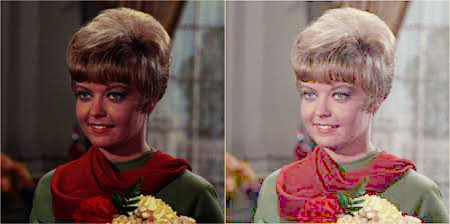

In [32]:
import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow

print(' Gamma Correction pada citra ')
print('----------------------------------')
try:
 gamma = int(input('Masukkan nilai Gamma: '))
except ValueError:
 print('Error, not a number')

# Baca citra grayscale
img = cv.imread('/content/drive/MyDrive/images/female.jpeg')

# Normalisasi dan lakukan koreksi gamma
gamma_corrected = np.array(255 * (img / 255) ** (1 / gamma), dtype='uint8')

image = np.hstack((img, gamma_corrected))

cv2_imshow(image)


2. Buat Simulasi Image Depth

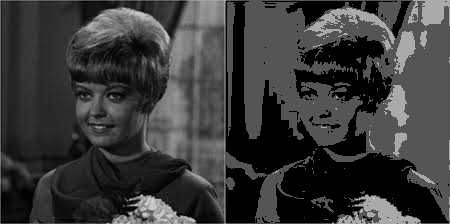

In [36]:
bit_depth=2
level = 255 / (pow(2,bit_depth)-1)
original = cv.imread('/content/drive/MyDrive/images/female.jpeg', cv.IMREAD_GRAYSCALE)
depth_image = np.round(original / level ) * level
depth_image = depth_image.astype(np.uint8)

image = np.hstack((original, depth_image))
cv2_imshow(image)

3. Buat modul Average Denoising

In [45]:
import cv2 as cv
import numpy as np
import glob
from math import log10, sqrt
from google.colab.patches import cv2_imshow

# --- Fungsi PSNR ---
def PSNR(img1, img2):
    mse = np.mean((img1 - img2) ** 2)
    if mse == 0:
        return 100
    max_pixel = 255.0
    psnr = 20 * log10(max_pixel / sqrt(mse))
    return psnr

# --- Baca citra asli ---
original = cv.imread('/content/drive/MyDrive/Polinema/Kuliah/PCVK/Images/galaxy.jpg') #path itu tidak bisa diakses

# --- Baca semua citra yang mengandung noise ---
cv_img = []
for img in glob.glob('/content/drive/MyDrive/Polinema/Kuliah/PCVK/Images/noises/*.jpg'): #path itu tidak bisa diakses
    n = cv.imread(img, cv.IMREAD_GRAYSCALE)
    cv_img.append(n)

# --- Daftar jumlah citra yang akan dirata-rata ---
jumlah_citra = [5, 10, 20, 40, 80, 100]

# --- Proses average denoising ---
for jumlah in jumlah_citra:
    avg_img = np.mean(cv_img[:jumlah], axis=0)   # hitung rata-rata pixel
    avg_img = np.uint8(avg_img)                  # ubah ke format gambar 8-bit

    psnr_value = PSNR(original, avg_img)
    print(f"PSNR untuk rata-rata {jumlah} citra = {psnr_value:.2f} dB")

    # Tampilkan hasil
    print(f"Hasil Average {jumlah} Citra:")
    cv2_imshow(avg_img)



/tmp/ipython-input-3735683632.py:31: RuntimeWarning: invalid value encountered in cast
  avg_img = np.uint8(avg_img)                  # ubah ke format gambar 8-bit


TypeError: unsupported operand type(s) for -: 'NoneType' and 'int'

karena tidak bisa akses path jadinya hasilnya error,average denoising ini membutuhkan banyak gambar noise yang berbeda,yang sebernanya udah disediain di path tersebut.

4. Buat image masking

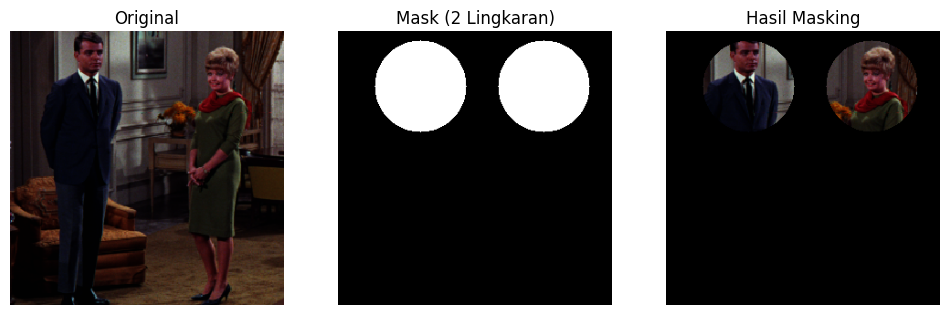

In [69]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Baca gambar
img = cv.imread('/content/drive/MyDrive/images/couple.png')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Buat mask kosong
mask = np.zeros(img.shape[:2], dtype="uint8")

# Ukuran gambar
h, w = img.shape[:2]

# Buat 2 lingkaran dengan posisi berbeda
y_pos = int(h*0.5) - 90 #untuk mengatur lingkaran agar lebih keatas
cv.circle(mask, (int(w*0.30), y_pos), 50, 255, -1)   # lingkaran kiri
cv.circle(mask, (int(w*0.75), y_pos), 50, 255, -1)   # lingkaran kanan

# Masking gabungan
masked = cv.bitwise_and(img, img, mask=mask)

# Tampilkan hasil
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(img); plt.title("Original"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(mask, cmap="gray"); plt.title("Mask (2 Lingkaran)"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(masked); plt.title("Hasil Masking"); plt.axis("off")
plt.show()


5. Menggunakan operator lain

NOT(komplemen)

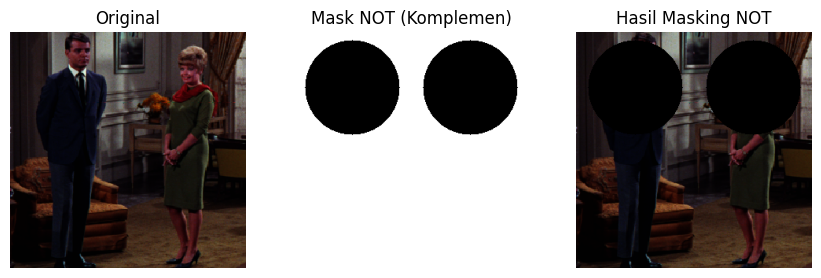

In [72]:
# Baca gambar
img = cv.imread('/content/drive/MyDrive/images/couple.png')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Buat mask lingkaran seperti sebelumnya
mask = np.zeros(img.shape[:2], dtype="uint8")

h, w = img.shape[:2]
y_pos = int(h*0.5) - 80
cv.circle(mask, (int(w*0.25), y_pos), 60, 255, -1)
cv.circle(mask, (int(w*0.75), y_pos), 60, 255, -1)

# Buat komplemen mask (NOT)
mask_not = cv.bitwise_not(mask)

# Terapkan mask dan komplemen mask

masked_not = cv.bitwise_and(img, img, mask=mask_not)

# Tampilkan hasil
plt.figure(figsize=(14,5))
plt.subplot(1,4,1); plt.imshow(img); plt.title("Original"); plt.axis("off")
plt.subplot(1,4,2); plt.imshow(mask_not, cmap="gray"); plt.title("Mask NOT (Komplemen)"); plt.axis("off")
plt.subplot(1,4,3); plt.imshow(masked_not); plt.title("Hasil Masking NOT"); plt.axis("off")
plt.show()


OR (Atau)

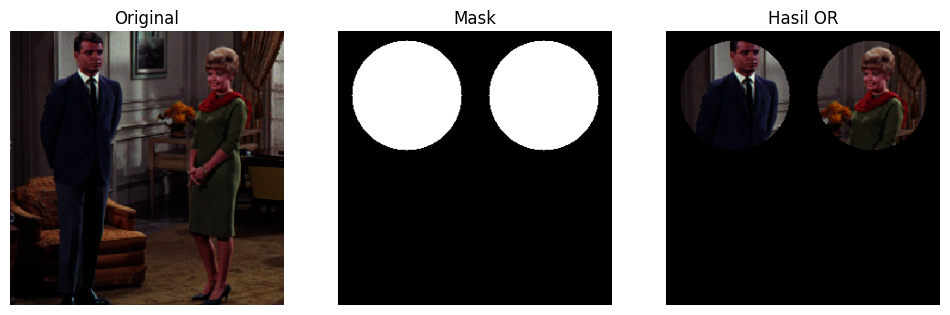

In [75]:
# Baca gambar
img = cv.imread('/content/drive/MyDrive/images/couple.png')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Buat mask lingkaran seperti sebelumnya
mask = np.zeros(img.shape[:2], dtype="uint8")

h, w = img.shape[:2]
y_pos = int(h*0.5) - 80
cv.circle(mask, (int(w*0.25), y_pos), 60, 255, -1)
cv.circle(mask, (int(w*0.75), y_pos), 60, 255, -1)

# OR
or_result = cv.bitwise_or(img, img, mask=mask)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(img); plt.title("Original"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(mask, cmap="gray"); plt.title("Mask"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(or_result); plt.title("Hasil OR"); plt.axis("off")
plt.show()




AND (Dan)

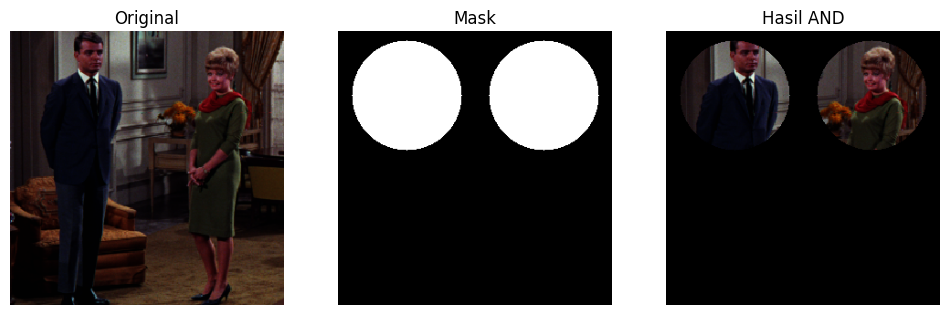

In [76]:
# Baca gambar
img = cv.imread('/content/drive/MyDrive/images/couple.png')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Buat mask lingkaran seperti sebelumnya
mask = np.zeros(img.shape[:2], dtype="uint8")

h, w = img.shape[:2]
y_pos = int(h*0.5) - 80
cv.circle(mask, (int(w*0.25), y_pos), 60, 255, -1)
cv.circle(mask, (int(w*0.75), y_pos), 60, 255, -1)

# AND
and_result = cv.bitwise_and(img, img, mask=mask)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(img); plt.title("Original"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(mask, cmap="gray"); plt.title("Mask"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(and_result); plt.title("Hasil AND"); plt.axis("off")
plt.show()

NAND (Not And)


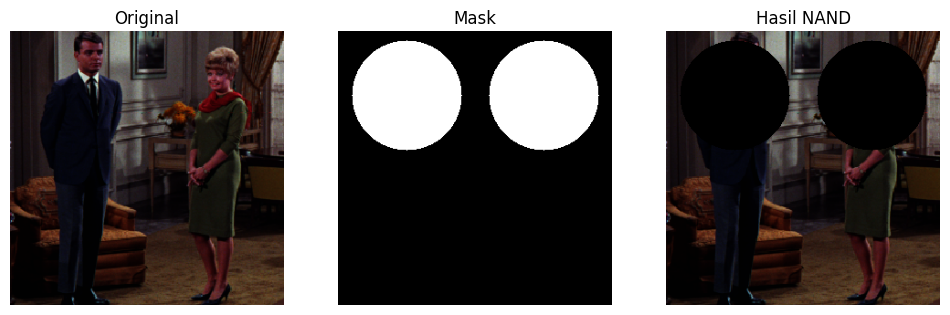

In [80]:
# Baca gambar
img = cv.imread('/content/drive/MyDrive/images/couple.png')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Buat mask lingkaran seperti sebelumnya
mask = np.zeros(img.shape[:2], dtype="uint8")

h, w = img.shape[:2]
y_pos = int(h*0.5) - 80
cv.circle(mask, (int(w*0.25), y_pos), 60, 255, -1)
cv.circle(mask, (int(w*0.75), y_pos), 60, 255, -1)

# NAND = NOT(AND)
nand_result = cv.bitwise_and(img, img, mask=cv.bitwise_not(mask))

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(img); plt.title("Original"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(mask, cmap="gray"); plt.title("Mask"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(nand_result); plt.title("Hasil NAND"); plt.axis("off")
plt.show()

XOR (Exlusive Or)

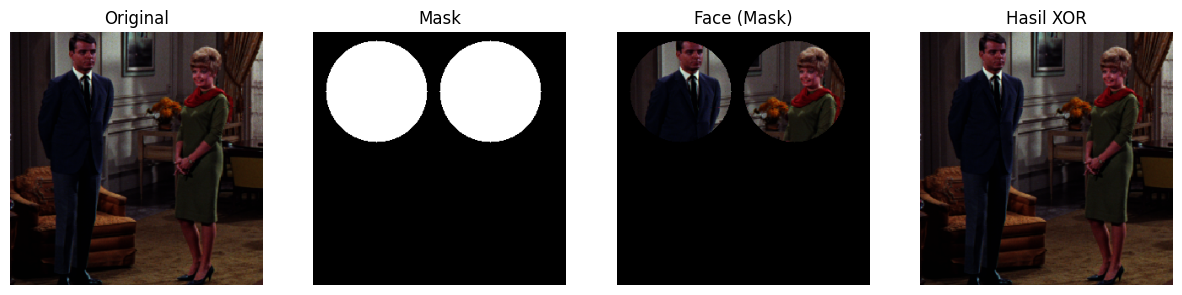

In [85]:
# Baca gambar
img = cv.imread('/content/drive/MyDrive/images/couple.png')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Buat mask lingkaran (area wajah)
mask = np.zeros(img.shape[:2], dtype="uint8")
h, w = img.shape[:2]
y_pos = int(h*0.5) - 80
cv.circle(mask, (int(w*0.25), y_pos), 60, 255, -1)
cv.circle(mask, (int(w*0.70), y_pos), 60, 255, -1)

# Buat inverse mask
mask_inv = cv.bitwise_not(mask)

# Pisahkan area wajah dan background
face = cv.bitwise_and(img, img, mask=mask)        # hanya wajah
background = cv.bitwise_and(img, img, mask=mask_inv)  # hanya background

# XOR wajah dengan background
xor_result = cv.bitwise_xor(face, background)

# Tampilkan hasil
plt.figure(figsize=(15,5))
plt.subplot(1,4,1); plt.imshow(img); plt.title("Original"); plt.axis("off")
plt.subplot(1,4,2); plt.imshow(mask, cmap="gray"); plt.title("Mask"); plt.axis("off")
plt.subplot(1,4,3); plt.imshow(face); plt.title("Face (Mask)"); plt.axis("off")
plt.subplot(1,4,4); plt.imshow(xor_result); plt.title("Hasil XOR"); plt.axis("off")
plt.show()

Hasil Analisa:
Pada percobaan ini dilakukan pengujian berbagai operator logika pada proses masking citra. Operator AND hanya menampilkan bagian citra yang berada pada area putih mask, sehingga hasilnya berupa potongan wajah berbentuk lingkaran sementara area lain menjadi hitam. Operator OR, karena menggunakan input gambar yang sama (img dengan img), memberikan hasil yang tampak sama dengan AND, yaitu hanya menampilkan bagian citra yang berada pada area putih mask. Operator NOT (Komplemen) bekerja dengan cara membalik mask, sehingga area wajah yang semula terlihat justru menjadi hitam, sedangkan bagian citra di luar lingkaran tetap ditampilkan. Pada operator NAND (Not AND), hasil yang diperoleh adalah kebalikan dari AND, yaitu area wajah menjadi hitam sedangkan latar belakang tetap muncul. Sementara itu, pada operator XOR (Exclusive OR), karena menggunakan mask dan mask inverse yang saling melengkapi, hasil akhirnya berupa gabungan wajah dan latar belakang yang menghasilkan citra utuh kembali seperti gambar asli. Dengan demikian dapat disimpulkan bahwa masing-masing operator logika memiliki perilaku yang khas dalam masking, meskipun pada kasus tertentu seperti AND dan OR hasilnya tampak sama karena operand yang digunakan identik.